In [25]:
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt

In [26]:
ls -lah | grep csv

-rw-r--r--@  1 elischwat  staff   2.3M Aug 14 15:31 NRKW1.csv
-rw-r--r--@  1 elischwat  staff   1.0M Aug 14 15:27 NRKW1_assim.csv
-rw-r--r--@  1 elischwat  staff   1.0M Aug 14 15:54 NRKW1_assim_uofa.csv
-rw-r--r--@  1 elischwat  staff   1.0M Aug 21 13:15 NRKW1_assim_uofa_with_ae.csv
-rw-r--r--@  1 elischwat  staff   943K Aug 21 13:15 NRKW1_assim_uofa_with_ae_aesc.csv
-rw-r--r--@  1 elischwat  staff   1.2M Aug 21 13:15 NRKW1_assim_uofa_with_ae_swe.csv
-rw-r--r--@  1 elischwat  staff   2.5M Aug 13 10:46 test_streamflow_output.csv
-rw-r--r--@  1 elischwat  staff   1.5M Aug 18 10:41 test_streamflow_output_swe=0.csv
-rw-r--r--@  1 elischwat  staff   1.5M Aug 18 10:41 test_streamflow_output_swe=1.csv
-rw-r--r--@  1 elischwat  staff   1.5M Aug 18 10:41 test_streamflow_output_swe=f(t).csv
-rw-r--r--@  1 elischwat  staff   2.4M Aug 13 10:39 test_swe_output.csv
-rw-r--r--@  1 elischwat  staff   995K Aug 18 10:41 test_swe_output_swe=0.csv
-rw-r--r--@  1 elischwat  staff   1.0M Aug 18 10:41 test_s

In [27]:
df = pd.read_csv("NRKW1_assim.csv").rename(columns={"sqin": 'SNODAS'}).set_index('datetime').join(
    pd.read_csv("NRKW1_assim_uofa.csv").rename(columns={"sqin": 'UofA'}).set_index('datetime')
).join(
    pd.read_csv("NRKW1_assim_uofa_with_ae.csv").rename(columns={"sqin": 'UofA w AE'}).set_index('datetime')
).join(
    pd.read_csv("NRKW1.csv").rename(columns={"sqin": 'Normal'}).set_index('datetime')
)

In [28]:
swe_model_df = pd.read_csv("NRKW1_assim_uofa_with_ae_swe.csv")
swe_model_df['datetime'] = pd.to_datetime(swe_model_df['datetime'])

swe_df_zone1 = pd.read_csv("/Users/elischwat/Development/snow_product_compare/swe_timeseries_NRKW1XZ1.csv", index_col=0)
swe_df_zone1['datetime'] = pd.to_datetime(swe_df_zone1[['year', 'month', 'day', 'hour']])
swe_df_zone2 = pd.read_csv("/Users/elischwat/Development/snow_product_compare/swe_timeseries_NRKW1XZ2.csv", index_col=0)
swe_df_zone2['datetime'] = pd.to_datetime(swe_df_zone2[['year', 'month', 'day', 'hour']])

ae_model_df = pd.read_csv("NRKW1_assim_uofa_with_ae_aesc.csv")
ae_model_df['datetime'] = pd.to_datetime(ae_model_df['datetime'])
ae_df_zone1 = pd.read_csv("/Users/elischwat/Development/snow_product_compare/ae_timeseries_NRKW1XZ1.csv", index_col=0)
ae_df_zone1['datetime'] = pd.to_datetime(ae_df_zone1[['year', 'month', 'day', 'hour']])
ae_df_zone2 = pd.read_csv("/Users/elischwat/Development/snow_product_compare/ae_timeseries_NRKW1XZ2.csv", index_col=0)
ae_df_zone2['datetime'] = pd.to_datetime(ae_df_zone2[['year', 'month', 'day', 'hour']])

Text(0.5, 0.98, 'SWE')

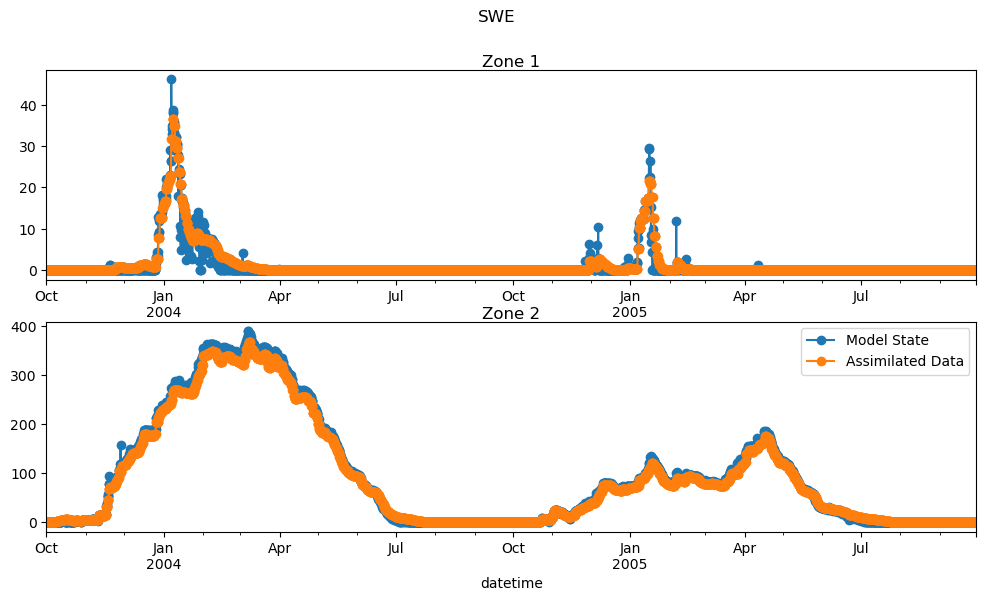

In [29]:
fig, axes = plt.subplots(2,1, figsize=(12,6))
swe_model_df.set_index('datetime')['NRKW1-1'].head(1460*2).plot(label = 'Model State', linestyle='-', marker="o", ax=axes[0])
swe_df_zone1.set_index('datetime')['uofa'].head(1460*2).plot(label = 'Assimilated Data', linestyle='-', marker="o", ax=axes[0])

swe_model_df.set_index('datetime')['NRKW1-2'].head(1460*2).plot(label = 'Model State', linestyle='-', marker="o", ax=axes[1])
swe_df_zone2.set_index('datetime')['uofa'].head(1460*2).plot(label = 'Assimilated Data', linestyle='-', marker="o", ax=axes[1])
axes[0].set_title('Zone 1', pad=0)
axes[1].set_title('Zone 2', pad=0)

plt.legend()
plt.suptitle('SWE')

Text(0.5, 0.98, 'AESC')

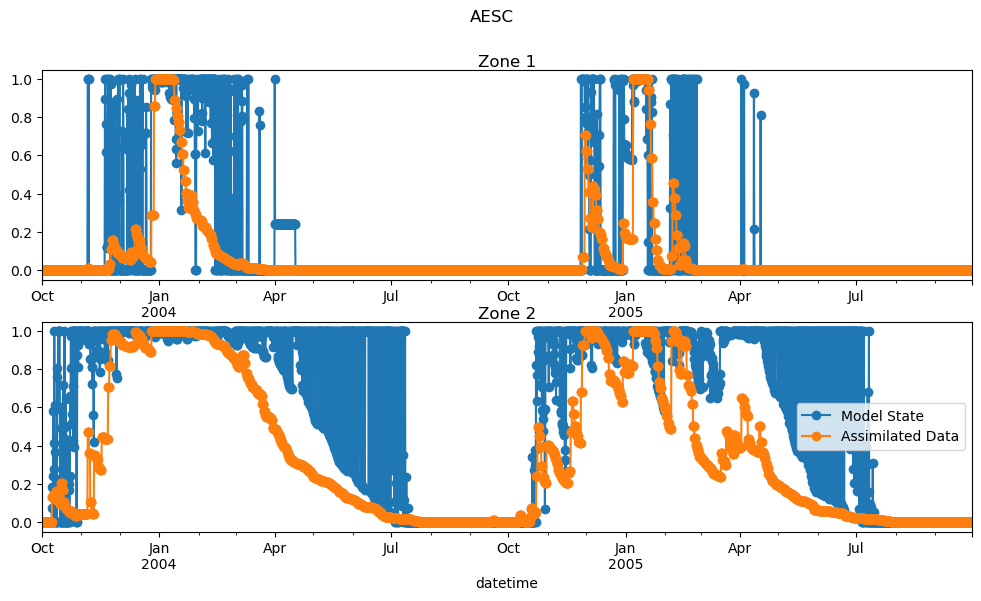

In [30]:
fig, axes = plt.subplots(2,1, figsize=(12,6))
ae_model_df.set_index('datetime')['NRKW1-1'].head(1460*2).plot(label = 'Model State', linestyle='-', marker="o", ax=axes[0])
ae_df_zone1.set_index('datetime')['uofa'].head(1460*2).plot(label = 'Assimilated Data', linestyle='-', marker="o", ax=axes[0])

ae_model_df.set_index('datetime')['NRKW1-2'].head(1460*2).plot(label = 'Model State', linestyle='-', marker="o", ax=axes[1])
ae_df_zone2.set_index('datetime')['uofa'].head(1460*2).plot(label = 'Assimilated Data', linestyle='-', marker="o", ax=axes[1])
axes[0].set_title('Zone 1', pad=0)
axes[1].set_title('Zone 2', pad=0)
# axes[0].set_xlim('20040320', '20040420')
# axes[1].set_xlim('20040320', '20040420')

plt.legend()
plt.suptitle('AESC')

<Axes: xlabel='datetime'>

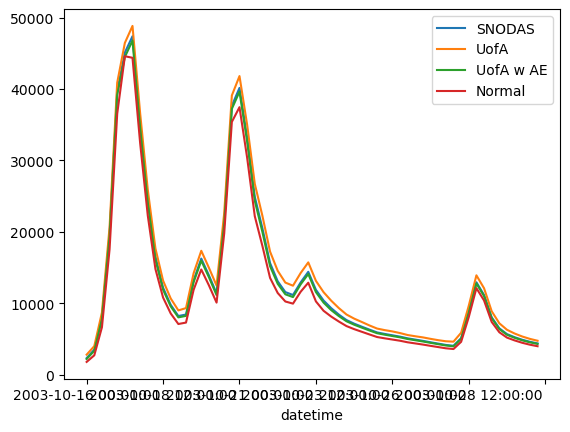

In [7]:
df.head(120).tail(60).plot()